In [40]:
# Import nessessasary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [4]:
# Create synathetic dataset
X,y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=4,
    n_redundant=6,
    n_repeated=0,
    n_classes=2,
    random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### Train Logistic Regression model

In [22]:
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediciton
y_pred = model.predict(X_test)

# Report
report = classification_report(y_pred, y_test)
print(report)

              precision    recall  f1-score   support

           0       0.69      0.66      0.67       127
           1       0.66      0.69      0.68       123

    accuracy                           0.68       250
   macro avg       0.68      0.68      0.68       250
weighted avg       0.68      0.68      0.68       250



Suppose this is the data of pnueuemonia patients so we will surely want higher recall. As we can't miss out any patient with pnueuemonia positive. So the true positive should be higher for it which is basically recall.

In [25]:
proababilities = model.predict_proba(X_test)[:,1]
y_pred = (proababilities > 0.4).astype(int)

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.75      0.57      0.65       122
           1       0.67      0.82      0.74       128

    accuracy                           0.70       250
   macro avg       0.71      0.70      0.69       250
weighted avg       0.71      0.70      0.70       250



In [27]:
# Calculate fpr,tpr and thresholds
fpr, tpr, thresholds = roc_curve(y_test, proababilities)
fpr[:5], tpr[:5], thresholds[:5]

(array([0.        , 0.        , 0.        , 0.00819672, 0.00819672]),
 array([0.       , 0.0078125, 0.265625 , 0.265625 , 0.2890625]),
 array([       inf, 0.97928246, 0.80890214, 0.80840719, 0.80207033]))

So I want my tpr to be 0.90, therefore my 90% of pnueuemonia cases can get correctly classified.

In [28]:
tpr

array([0.       , 0.0078125, 0.265625 , 0.265625 , 0.2890625, 0.2890625,
       0.296875 , 0.296875 , 0.34375  , 0.34375  , 0.3515625, 0.3515625,
       0.375    , 0.375    , 0.3984375, 0.3984375, 0.4296875, 0.4296875,
       0.4375   , 0.4375   , 0.4609375, 0.4609375, 0.46875  , 0.46875  ,
       0.4765625, 0.4765625, 0.484375 , 0.484375 , 0.4921875, 0.4921875,
       0.5078125, 0.5078125, 0.515625 , 0.515625 , 0.5390625, 0.5390625,
       0.5546875, 0.5546875, 0.5859375, 0.5859375, 0.625    , 0.625    ,
       0.640625 , 0.640625 , 0.6484375, 0.6484375, 0.65625  , 0.65625  ,
       0.71875  , 0.71875  , 0.75     , 0.75     , 0.7578125, 0.7578125,
       0.765625 , 0.765625 , 0.7734375, 0.7734375, 0.7890625, 0.7890625,
       0.796875 , 0.796875 , 0.84375  , 0.84375  , 0.8515625, 0.8515625,
       0.859375 , 0.859375 , 0.8671875, 0.8671875, 0.875    , 0.875    ,
       0.8828125, 0.8828125, 0.890625 , 0.890625 , 0.90625  , 0.90625  ,
       0.9140625, 0.9140625, 0.921875 , 0.921875 , 

In [35]:
# find the index of 0.90 tpr so we can find corresponding threshold value to it
desired_recall = 0.90
closest_index = np.argmin(abs(tpr-desired_recall))
closest_index # found out that index

76

In [36]:
# Check threshold and fpr value for that index
thresholds[closest_index], fpr[closest_index] 

(0.26349585272229664, 0.7049180327868853)

* Now almost 90% patients with actual pnueuemonia positive will be correctly classified as pnueuemonia positive.
* But as can see that fpr(False Positive Ratio) value increased too much means, almost 70% patients with pnueuemonia negative will also be classified as pnueuemonia positive. It's such a high number. We need to find balance between these two.

Let's try now 0.80 desired recall.

In [37]:
# find the index of 0.80 tpr so we can find corresponding threshold value to it
desired_recall = 0.80
closest_index = np.argmin(abs(tpr-desired_recall))
closest_index # found out that index

60

In [38]:
# Check threshold and fpr value for that index
thresholds[closest_index], fpr[closest_index] 

(0.4236689405793843, 0.4180327868852459)

Now fpr value is preety decent and balanced.

In [42]:
# Find AUC
area = auc(fpr, tpr)
area

0.764856557377049

So area under curve is around 76%

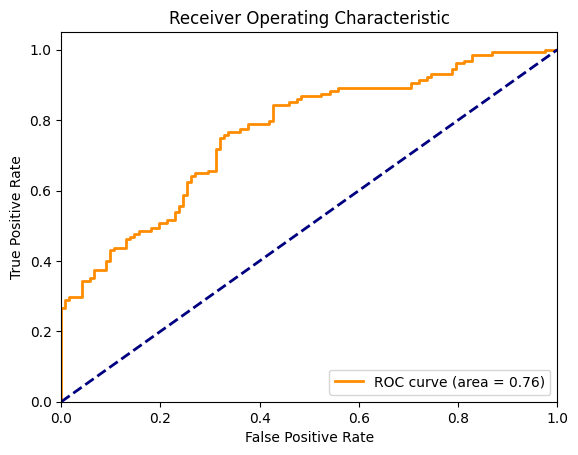

In [43]:
# Let's visualize roc curve now
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw = 2, label = "ROC curve (area = %0.2f)" % area)
plt.plot([0,1], [0,1], color = 'navy', lw = 2, linestyle = '--' )
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc = "lower right")
plt.show()

### Train XGboost Classifier Model

In [46]:
# train model
model = XGBClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Report
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       122
           1       0.94      0.88      0.91       128

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250



In [53]:
# Let's get roc values for this one
y_scores = model.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_scores)
area2 = auc(fpr_xgb, tpr_xgb)
area2

0.9501152663934426

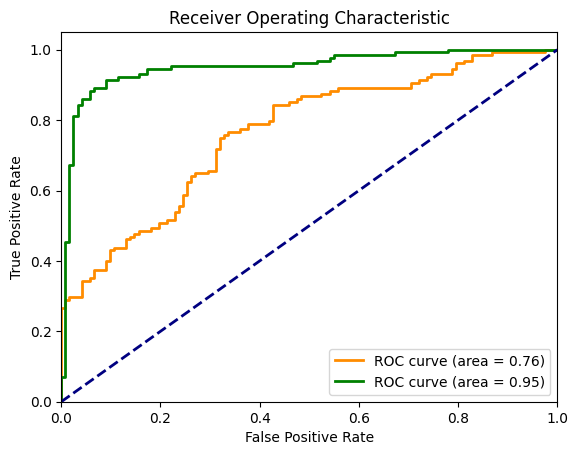

In [55]:
# Let's visualize roc curve for this one also now
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw = 2, label = "ROC curve (area = %0.2f)" % area)
plt.plot(fpr_xgb, tpr_xgb, color='green', lw = 2, label = "ROC curve (area = %0.2f)" % area2)
plt.plot([0,1], [0,1], color = 'navy', lw = 2, linestyle = '--' )
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc = "lower right")
plt.show()

As you can see the green line is much better than orange line as it covers more area and it has has higher recall and precision values.

Now let's try to achieve 92% recall in this XGBoost model.

In [59]:
desired_recall = 0.92
closest_index = np.argmin(abs(tpr_xgb - desired_recall))
closest_index

23

In [61]:
# Check threshold and fpr value for that index
thresholds_xgb[closest_index], fpr_xgb[closest_index] 

(0.3286321, 0.11475409836065574)

In [62]:
y_pred = (y_scores > 0.3286321).astype(int)

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.89      0.90       122
           1       0.89      0.91      0.90       128

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250

